In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")

# Funciones auxiliares para estimar y graficar distribuciones empíricas.
# Se definen acá porque se usan más adelante en el notebook.
def CDF(data):
    """Retorna la función de distribución acumulada empírica como una Serie de pandas."""
    data = pd.Series(data).dropna().sort_values()
    n = len(data)
    if n == 0:
        return pd.Series(dtype=float)
    probs = np.arange(1, n + 1) / n
    return pd.Series(probs, index=data.to_numpy())


def PDF(data, bins=40):
    """Retorna una aproximación empírica de la densidad usando histograma normalizado."""
    data = pd.Series(data).dropna()
    if len(data) == 0:
        return pd.Series(dtype=float)
    counts, edges = np.histogram(data, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    return pd.Series(counts, index=centers)


ModuleNotFoundError: No module named 'seaborn'

# IMT3860: Análisis Exploratorio de Datos (EDA).



## Introducción.

En este ejercicio, realizaremos un análisis exploratorio de los resultados de la encuesta **General Social Survey (GSS)**, realizada anualmente en EEUU desde 1972, a muestras de población adulta a las cuales se les hacen preguntas demográficas, y sobre preferencias sociales y políticas. Es ampliamente usada por políticos, legisladores e investigadores.

https://gss.norc.org/

Los datos que acompañan a este ejercicio corresponden a un extracto del dataset completo, y ya han sido limpiados y validados

https://gss.norc.org/Documents/codebook/GSS%202021%20Codebook%20R1.pdf

Variable: GUNLAW Type: Numeric
Label:
Would you favor or oppose a law which would require a person to obtain a police permit
before he or she could buy a gun?
1: a favor
2: en contra

Variable: GRASSV Type: Numeric
Label:
Do you think the use of marijuana should be made legal or not?
1: a favor
2: en contra

Race (97 imputed values, six categories):
• White
• African-American
CODEBOOK | 24
• American Indian/Alaska Native
• Asian
• Native Hawaiian or Other Pacific Islander


## Análisis Exploratorio Estadístico.

### 1. Lea e inspeccione los datos. 

Identifique el significado de cada variable en el dataset. Para ello, vea el libro de código disponible en el siguiente link:<br>

https://gss.norc.org/Documents/codebook/GSS%202021%20Codebook%20R1.pdf

Tip: puede buscar las variables usando Ctrl+F (find).


**Nota técnica:** para leer archivos `.hdf5` con `pandas`, debe estar instalada la librería `tables` / `pytables`.  
Desde la consola de Windows puede instalarse con:

```bash
py -m pip install tables
```


In [ ]:
from pathlib import Path

data_path = Path("gss.hdf5")

if not data_path.exists():
    raise FileNotFoundError(
        "No se encontró el archivo 'gss.hdf5'. "
        "Debe estar en la misma carpeta que este notebook."
    )

try:
    import tables  # requerido por pandas para leer HDF5
except ImportError as e:
    raise ImportError(
        "Falta instalar la librería 'tables' / 'pytables'. "
        "Desde la consola ejecute: py -m pip install tables"
    ) from e

# Si el archivo tiene una única key interna, la leemos automáticamente.
with pd.HDFStore(data_path, mode="r") as store:
    keys = store.keys()
    print("Objetos disponibles dentro del archivo HDF5:", keys)

    if len(keys) == 1:
        gss = store[keys[0]]
    else:
        raise ValueError(
            "El archivo HDF5 tiene más de una key. "
            "Revise las keys impresas arriba y lea el archivo con: "
            "pd.read_hdf('gss.hdf5', key='nombre_de_la_key')"
        )

print(gss.shape)
display(gss.head())


Objetos disponibles dentro del archivo HDF5: ['/gss']
(62466, 10)


,year,age,cohort,sex,race,educ,realinc,gunlaw,grass,wtssall
0,1972,26.0,1946.0,1,1,18.0,13537.0,2.0,NaN,0.8893
1,1972,38.0,1934.0,2,1,12.0,18951.0,1.0,NaN,0.4446
2,1972,57.0,1915.0,1,1,12.0,30458.0,1.0,NaN,1.3339
3,1972,61.0,1911.0,2,1,14.0,37226.0,1.0,NaN,0.8893
4,1972,59.0,1913.0,1,1,12.0,30458.0,2.0,NaN,0.8893


### 2. Usando tablas pivote u otro método de agrupación de datos, determine:

* La cantidad de razas considerada en la encuesta.
* El número total de encuestados por sexo, raza.
* El ingreso promedio por año de la encuesta.

In [ ]:
# Cantidad de razas consideradas en la encuesta
n_razas = gss["race"].nunique(dropna=True)
print("Cantidad de razas consideradas:", n_razas)

# Número total de encuestados por sexo y raza
pv_sex_race = pd.pivot_table(
    gss,
    index="sex",
    columns="race",
    values="year",
    aggfunc="count",
    margins=True
)

pv_sex_race


Cantidad de razas consideradas: 3


race,1,2,3,All
sex,,,,
1,23276,3587,1783,28646
2,26941,4985,1894,33820
All,50217,8572,3677,62466


,realinc
year,
1972,30674.574863
1973,34133.554448
1974,34753.956361
1975,32368.364613
1976,31694.194505
1977,34648.161850
1978,33786.501059
1980,34975.811377
1982,27170.082067


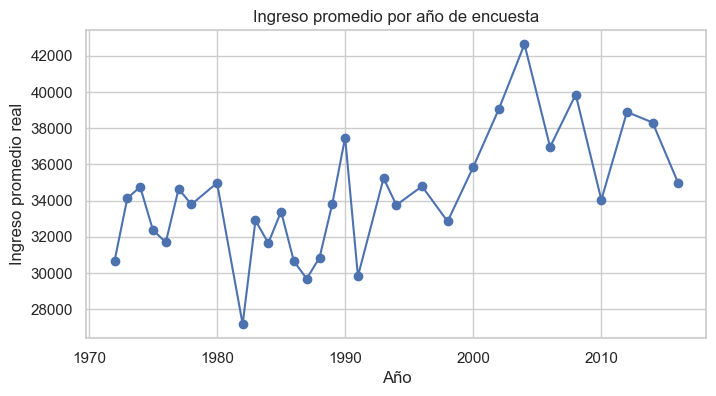

In [ ]:
# Ingreso promedio por año de la encuesta
pv_income_year = pd.pivot_table(
    gss,
    index="year",
    values="realinc",
    aggfunc="mean"
)

display(pv_income_year)

ax = pv_income_year.plot(
    marker="o",
    figsize=(8, 4),
    legend=False
)
ax.set_title("Ingreso promedio por año de encuesta")
ax.set_xlabel("Año")
ax.set_ylabel("Ingreso promedio real")
plt.show()


### 3. Análisis univariado.

Primero analizaremos la variable `educ`. ¿Qué podemos aprender de su distribución y comportamiento?
Utilizando análisis estadístico y gráfico, analice:
* Calcule y grafique las métricas de tendencia central y dispersión de `educ`.
* Analice la distribución completa de `educ`. Genere una curva de distribución de probabilidad.
* Determine: ¿cuál es la fracción de encuestados con educación media completa (12 años)? ¿Y con educación universitaria de pregrado (16 años)? Puede responder usando un histograma acumulado, o cálculos estadísticos.


Resumen estadístico de educ:


count    62304.000000
mean        12.831311
std          3.117027
min          0.000000
25%         12.000000
50%         12.000000
75%         15.000000
max         20.000000
Name: educ, dtype: float64

Media: 12.831310991268618
Mediana: 12.0
Moda: 12.0
Desviación estándar: 3.117027051466134
Rango intercuartílico: 3.0
Fracción con educación media completa (12 años): 30.73%
Fracción con educación universitaria de pregrado (16 años): 12.76%


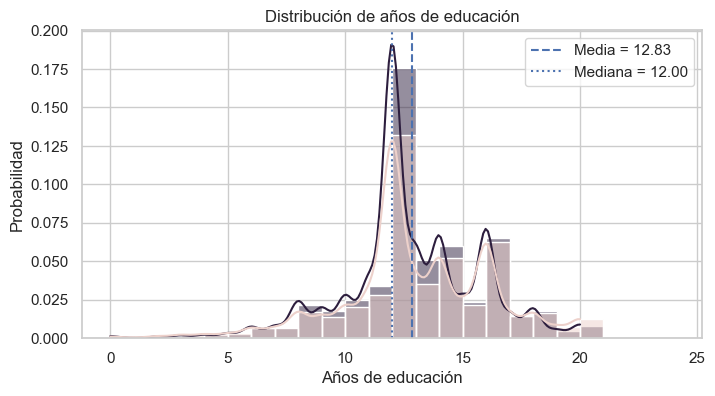

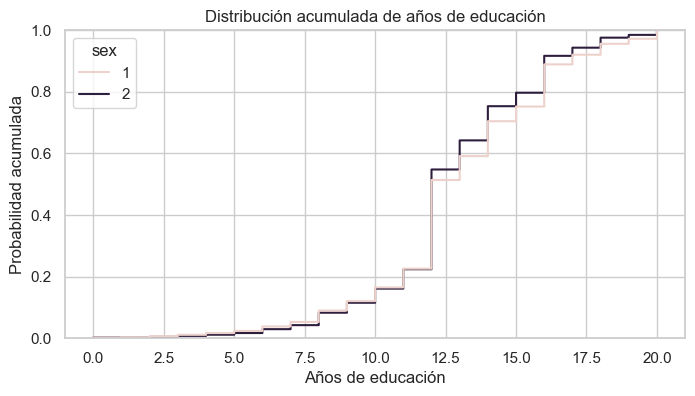

In [ ]:
educ = gss["educ"].dropna()

print("Resumen estadístico de educ:")
display(educ.describe())

print("Media:", educ.mean())
print("Mediana:", educ.median())
print("Moda:", educ.mode().iloc[0])
print("Desviación estándar:", educ.std())
print("Rango intercuartílico:", educ.quantile(0.75) - educ.quantile(0.25))

frac_12 = (educ == 12).mean()
frac_16 = (educ == 16).mean()

print(f"Fracción con educación media completa (12 años): {frac_12:.2%}")
print(f"Fracción con educación universitaria de pregrado (16 años): {frac_16:.2%}")

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=gss,
    x="educ",
    hue="sex",
    stat="probability",
    kde=True,
    bins=np.arange(0, 25, 1),
    ax=ax
)

ax.axvline(educ.mean(), linestyle="--", label=f"Media = {educ.mean():.2f}")
ax.axvline(educ.median(), linestyle=":", label=f"Mediana = {educ.median():.2f}")

ax.set_title("Distribución de años de educación")
ax.set_xlabel("Años de educación")
ax.set_ylabel("Probabilidad")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.ecdfplot(data=gss, x="educ", hue="sex", ax=ax)
ax.set_title("Distribución acumulada de años de educación")
ax.set_xlabel("Años de educación")
ax.set_ylabel("Probabilidad acumulada")
plt.show()


### 4. Análisis multivariado.

* Analice la distribución de `educ` por raza y sexo. ¿Hay diferencias significativas, o son similares?
* Suponga los siguientes niveles educacionales: educación media o menos (`educ <= 12`), pregrado (`13 <= educ <= 16`) y postgrado (`educ > 16`). Analice: ¿hay diferencias en los niveles de ingreso de acuerdo al nivel educacional?


Por ejemplo, comparemos la distribución de ingresos para distintos niveles de educación.

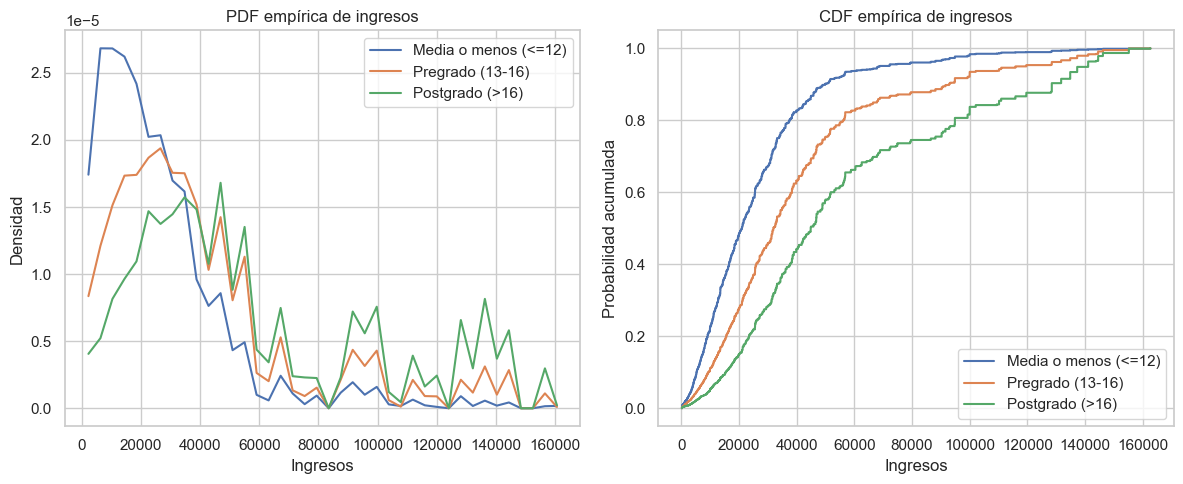

In [ ]:
inc = gss["realinc"]
educ = gss["educ"]

media = inc[educ <= 12]
pregrado = inc[(educ > 12) & (educ <= 16)]
postgrado = inc[educ > 16]

elevel = {
    "Media o menos (<=12)": media,
    "Pregrado (13-16)": pregrado,
    "Postgrado (>16)": postgrado
}

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, xlabel="Ingresos", ylabel="Densidad")
ax2 = fig.add_subplot(122, xlabel="Ingresos", ylabel="Probabilidad acumulada")

for nombre, datos in elevel.items():
    datos = pd.Series(datos).dropna()

    pdf = PDF(datos)
    cdf = CDF(datos)

    pdf.plot(kind="line", ax=ax1, label=nombre)
    cdf.plot(kind="line", ax=ax2, label=nombre, drawstyle="steps-post")

ax1.set_title("PDF empírica de ingresos")
ax2.set_title("CDF empírica de ingresos")
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()


Como conclusión, el análisis exploratorio mediante CDF permite verificar si existen diferencias relevantes entre distribuciones.

En este caso, si la CDF de un grupo queda desplazada hacia la derecha respecto de otra, eso indica que ese grupo tiende a presentar mayores niveles de ingreso. Por lo tanto, al comparar los niveles educacionales, podemos observar si los grupos con mayor educación muestran ingresos sistemáticamente mayores.

En general, las CDF suelen ser menos ruidosas que las PDF, por lo que permiten apreciar mejor las diferencias globales entre distribuciones. Como resumen, las CDF suelen ser recomendables para análisis exploratorio, ya que:

- entregan una visualización clara de la distribución de una variable;
- no dependen tanto de la elección del número de bins;
- permiten comparar distribuciones, sobre todo si son más de dos.


### Modelando la distribución de probabilidad.

Otro análisis de interés en un análisis exploratorio, es verificar si una variable sigue una distribución de probabilidad  conocida, por ejemplo, una normal o lognormal. Para ello, podemos comparar la CDF o PDF obtenidas a partir de los datos, con la distribución teórica.

Por ejemplo, en muchos datasets la distribución del ingreso es aproximadamente lognormal, lo cual significa que el logaritmo sigue una distribución normal. Verifiquemos si esto es cierto para los datos del GSS.
Primero, calculamos la media y desviación estándar de `log(inc)`, y usamos estos valores para construir un objeto `norm` con la función `scipy.stats.norm()`.



<div>
<img src="attachment:image.png" align="center" width="300"/>
</div>


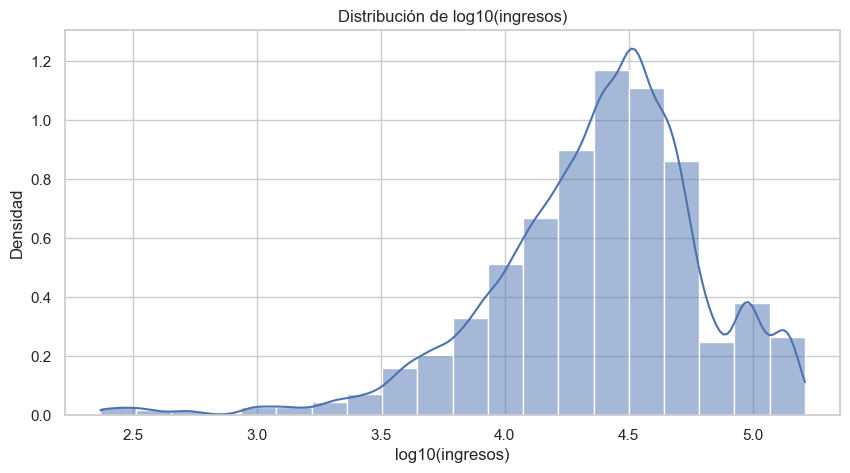

In [ ]:
# ¿Cómo se comportan los ingresos y el logaritmo de los ingresos?
# Usamos solamente ingresos positivos, porque log10 no está definido para valores <= 0.
inc_pos = gss.loc[gss["realinc"] > 0, "realinc"].dropna()
log_inc = np.log10(inc_pos)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(log_inc, bins=20, kde=True, stat="density", ax=ax)
ax.set_title("Distribución de log10(ingresos)")
ax.set_xlabel("log10(ingresos)")
ax.set_ylabel("Densidad")
plt.show()


Media: 4.371148677934172
Desviación estándar: 0.4290082383271385


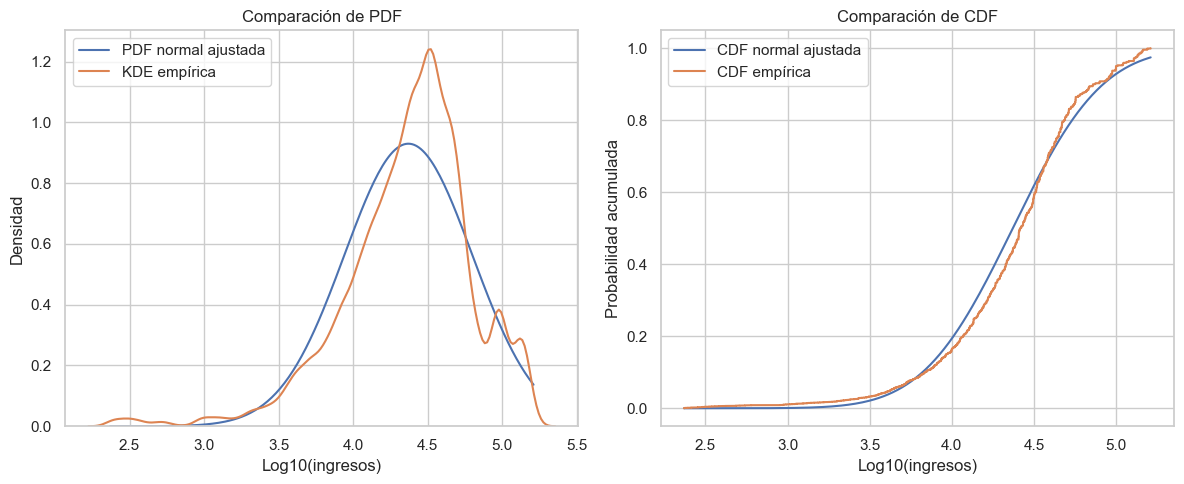

In [ ]:
from scipy.stats import norm

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, xlabel="Log10(ingresos)", ylabel="Densidad")
ax2 = fig.add_subplot(122, xlabel="Log10(ingresos)", ylabel="Probabilidad acumulada")

# Calcular media y desviación estándar
mean = log_inc.mean()
std = log_inc.std()
print("Media:", mean)
print("Desviación estándar:", std)

# Construir un objeto normal
dist = norm(loc=mean, scale=std)

# Evaluar la PDF y CDF normal en el rango observado
xs = np.linspace(log_inc.min(), log_inc.max(), 200)
dist_pdf = dist.pdf(xs)
dist_cdf = dist.cdf(xs)

# Comparar PDF empírica con PDF normal
ax1.plot(xs, dist_pdf, label="PDF normal ajustada")
sns.kdeplot(log_inc, ax=ax1, label="KDE empírica")

# Comparar CDF empírica con CDF normal
ax2.plot(xs, dist_cdf, label="CDF normal ajustada")
cdf = CDF(log_inc)
cdf.plot(ax=ax2, label="CDF empírica", drawstyle="steps-post")

ax1.set_title("Comparación de PDF")
ax2.set_title("Comparación de CDF")
ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()


## 5. Explorando relaciones entre variables.

Analicemos por ejemplo la relación entre ingresos y edad. Tenemos varios datos por rango de edad, por lo tanto necesitamos agruparlos y calcular el ingreso promedio por rango de edad y nivel de educación. Para esto, usamos la función `groupby`.



Index(['year', 'age', 'cohort', 'sex', 'race', 'educ', 'realinc', 'gunlaw',
       'grass', 'wtssall'],
      dtype='object')

,year,age,cohort,sex,race,educ,realinc,gunlaw,grass,wtssall
0,1972,26.0,1946.0,1,1,18.0,13537.0,2.0,NaN,0.8893
1,1972,38.0,1934.0,2,1,12.0,18951.0,1.0,NaN,0.4446
2,1972,57.0,1915.0,1,1,12.0,30458.0,1.0,NaN,1.3339
3,1972,61.0,1911.0,2,1,14.0,37226.0,1.0,NaN,0.8893
4,1972,59.0,1913.0,1,1,12.0,30458.0,2.0,NaN,0.8893
5,1972,46.0,1926.0,1,1,8.0,18951.0,2.0,NaN,0.8893
6,1972,43.0,1929.0,2,2,8.0,2707.0,1.0,NaN,0.8893
7,1972,72.0,1900.0,2,2,12.0,8122.0,NaN,NaN,0.8893
8,1972,85.0,1887.0,1,1,16.0,30458.0,2.0,NaN,0.8893
9,1972,44.0,1928.0,1,1,12.0,24366.0,1.0,NaN,0.8893


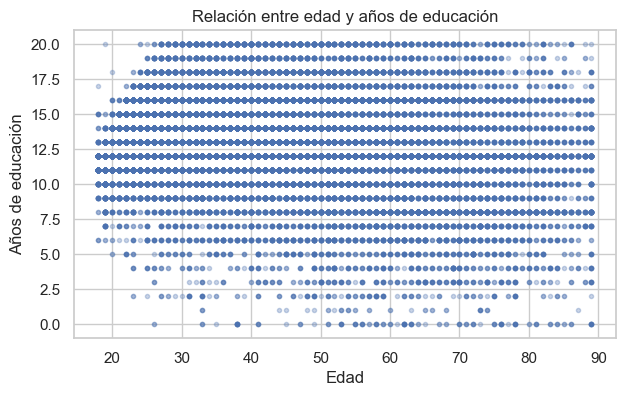

In [ ]:
display(gss.columns)
display(gss.head(20))

plt.figure(figsize=(7, 4))
plt.plot(gss["age"], gss["educ"], ".", alpha=0.3)
plt.xlabel("Edad")
plt.ylabel("Años de educación")
plt.title("Relación entre edad y años de educación")
plt.show()


In [ ]:
# Primero agrupamos por edad y calculamos el ingreso promedio
inc_age = gss.groupby("age")["realinc"].mean().dropna()
display(inc_age.head())


age
18.0    36696.140255
19.0    33456.860419
20.0    26806.371609
21.0    27161.578191
22.0    27965.731410
Name: realinc, dtype: float64

In [ ]:
# ¿Hay relación entre ingreso promedio y edad?
age = inc_age.index.to_numpy()
income_age = inc_age.to_numpy()

pearson = np.corrcoef(income_age, age)[0, 1]
print("Pearson:", pearson)


Pearson: -0.5076280590964728


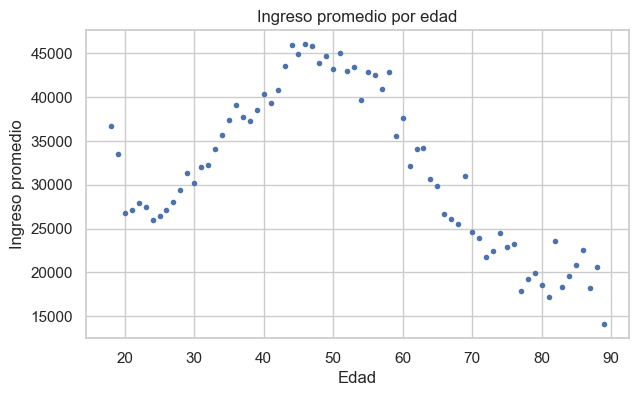

In [ ]:
# ¿Cómo es la relación?
plt.figure(figsize=(7, 4))
plt.plot(inc_age.index, inc_age.values, ".")
plt.xlabel("Edad")
plt.ylabel("Ingreso promedio")
plt.title("Ingreso promedio por edad")
plt.show()


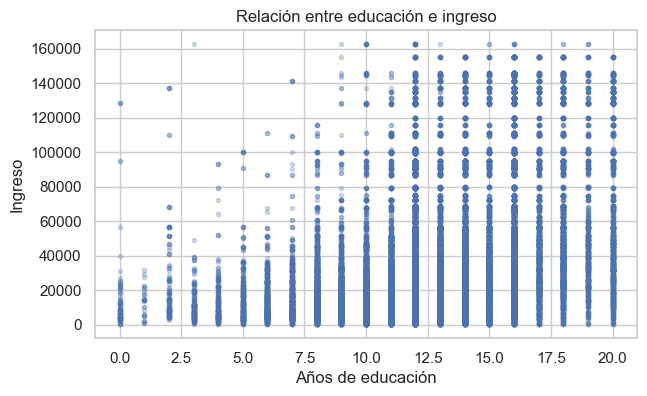

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(gss["educ"], gss["realinc"], ".", alpha=0.25)
plt.xlabel("Años de educación")
plt.ylabel("Ingreso")
plt.title("Relación entre educación e ingreso")
plt.show()


Correlación entre educación e ingreso promedio: 0.9129166243732301


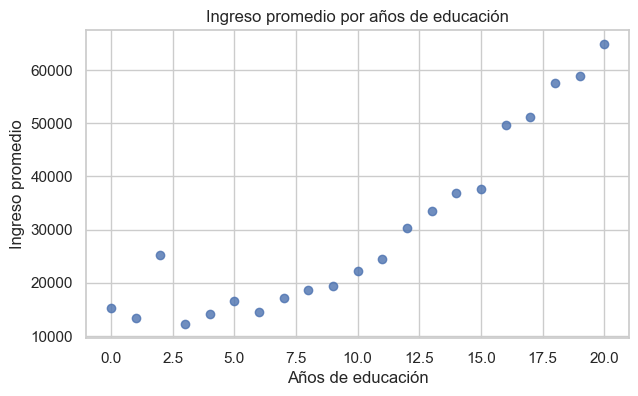

In [ ]:
# Ahora exploramos la relación años de educación - ingreso promedio
inc_educ = gss.groupby("educ")["realinc"].mean().dropna()

corr_educ_income = np.corrcoef(
    inc_educ.index.to_numpy(),
    inc_educ.to_numpy()
)[0, 1]

print("Correlación entre educación e ingreso promedio:", corr_educ_income)

plt.figure(figsize=(7, 4))
plt.plot(inc_educ.index, inc_educ.values, "o", alpha=0.8)
plt.xlabel("Años de educación")
plt.ylabel("Ingreso promedio")
plt.title("Ingreso promedio por años de educación")
plt.show()


In [ ]:
# Probemos una regresión lineal simple
from scipy.stats import linregress

res = linregress(inc_educ.index.to_numpy(), inc_educ.to_numpy())
print(res)


LinregressResult(slope=np.float64(2495.4842910430543), intercept=np.float64(5203.512675387352), rvalue=np.float64(0.9129166243732301), pvalue=np.float64(7.904399771219237e-09), stderr=np.float64(255.95438397657068), intercept_stderr=np.float64(2992.2224258622314))


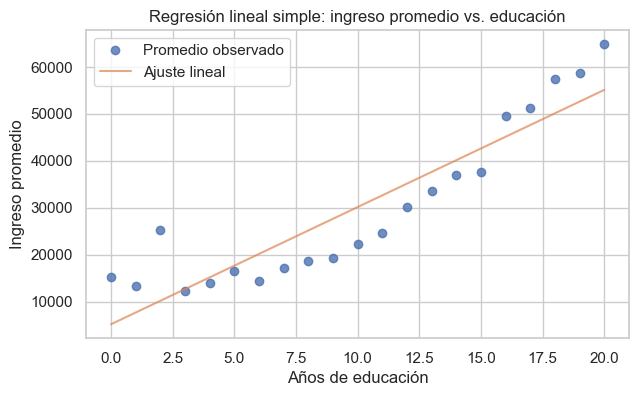

In [ ]:
fx = np.array([inc_educ.index.min(), inc_educ.index.max()])
fy = res.intercept + res.slope * fx

plt.figure(figsize=(7, 4))
plt.plot(inc_educ.index, inc_educ.values, "o", alpha=0.8, label="Promedio observado")
plt.plot(fx, fy, "-", alpha=0.7, label="Ajuste lineal")

plt.xlabel("Años de educación")
plt.ylabel("Ingreso promedio")
plt.title("Regresión lineal simple: ingreso promedio vs. educación")
plt.legend()
plt.show()


In [ ]:
try:
    import statsmodels.formula.api as smf
except ImportError as e:
    raise ImportError(
        "Falta instalar statsmodels. Desde la consola ejecute: py -m pip install statsmodels"
    ) from e

# ¿Es un buen ajuste? Tal vez podemos probar con una función no lineal.
# Preparamos datos sin valores faltantes para el modelo.
model_data = gss[["realinc", "educ", "age"]].dropna().copy()

# Agregamos nuevas columnas: educ**2 y age**2
model_data["educ2"] = model_data["educ"] ** 2
model_data["age2"] = model_data["age"] ** 2

# Modelo de regresión con educ, educ2, age y age2
results = smf.ols("realinc ~ educ + educ2 + age + age2", data=model_data).fit()

# Parámetros estimados
display(results.params)


Intercept   -23241.884034
educ          -528.309369
educ2          159.966740
age           1696.717149
age2           -17.196984
dtype: float64

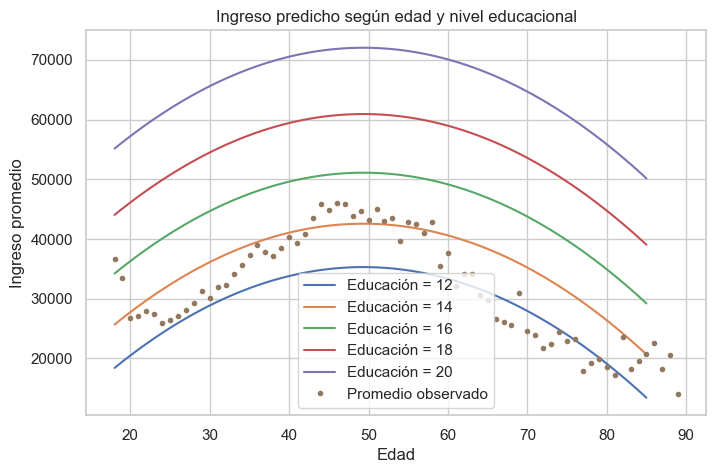

In [ ]:
plt.figure(figsize=(8, 5))

for ey in [12, 14, 16, 18, 20]:
    df_pred = pd.DataFrame()
    df_pred["age"] = np.linspace(18, 85, 100)
    df_pred["age2"] = df_pred["age"] ** 2

    # Fijamos el nivel educacional en un valor común
    df_pred["educ"] = ey
    df_pred["educ2"] = df_pred["educ"] ** 2

    pred = results.predict(df_pred)

    plt.plot(df_pred["age"], pred, "-", label=f"Educación = {ey}")

plt.plot(inc_age.index, inc_age.values, ".", label="Promedio observado")
plt.xlabel("Edad")
plt.ylabel("Ingreso promedio")
plt.title("Ingreso predicho según edad y nivel educacional")
plt.legend()
plt.show()

# Ejercicio: repetir el análisis para otros niveles educacionales.


In [ ]:
# Construimos un DataFrame para predecir ingresos variando educación,
# manteniendo fija la edad en 30 años.
df_pred_educ = pd.DataFrame()
df_pred_educ["educ"] = np.linspace(0, 20, 100)
df_pred_educ["age"] = 30
df_pred_educ["educ2"] = df_pred_educ["educ"] ** 2
df_pred_educ["age2"] = df_pred_educ["age"] ** 2

# Generar predicciones
pred = results.predict(df_pred_educ)
display(pred.head())


0    12182.344976
1    12082.144399
2    11995.000999
3    11920.914776
4    11859.885730
dtype: float64

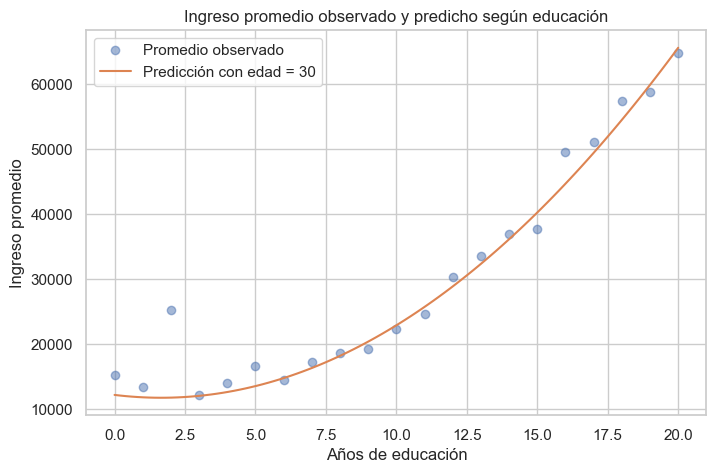

In [ ]:
# Graficar ingreso medio observado en cada grupo educacional
plt.figure(figsize=(8, 5))

mean_income_by_educ = gss.groupby("educ")["realinc"].mean().dropna()
plt.plot(
    mean_income_by_educ.index,
    mean_income_by_educ.values,
    "o",
    alpha=0.5,
    label="Promedio observado"
)

# Graficar predicción para edad fija de 30 años
plt.plot(df_pred_educ["educ"], pred, label="Predicción con edad = 30")

plt.xlabel("Años de educación")
plt.ylabel("Ingreso promedio")
plt.title("Ingreso promedio observado y predicho según educación")
plt.legend()
plt.show()


# Taller individual o en parejas: Exploración adicional de la GSS

Este taller debe ser desarrollado de manera **individual o en equipos de máximo 2 personas**. La idea es profundizar el análisis exploratorio usando la misma base de datos `gss.hdf5` trabajada en la clase.

El producto esperado es una sección final del notebook que contenga, para cada pregunta:

- una breve explicación del objetivo del análisis;
- el código utilizado;
- al menos una tabla o visualización relevante;
- una interpretación escrita de los resultados, evitando limitarse a describir el gráfico.

---

## Pregunta 1. Caracterización general de la muestra según variables demográficas  
**Dificultad: normal**

Realice una caracterización inicial de la muestra utilizando las variables `year`, `sex`, `race`, `age` y `educ`.

En particular, responda:

1. ¿Cuántas observaciones hay por año de encuesta?
2. ¿Cómo se distribuyen las personas encuestadas según sexo y raza?
3. ¿Cuál es la edad promedio y la educación promedio de los encuestados?
4. ¿Se observan cambios relevantes en la composición de la muestra a través del tiempo?

**Sugerencias de análisis:**

- Use `groupby`, `pivot_table` o `value_counts`.
- Construya al menos una tabla resumen y un gráfico de barras o línea.
- Comente si la muestra parece equilibrada o si hay grupos con mayor representación.

---

## Pregunta 2. Educación e ingreso: comparación exploratoria entre grupos  
**Dificultad: normal**

Analice la relación entre los años de educación (`educ`) y el ingreso real (`realinc`). Para facilitar la comparación, construya una nueva variable de nivel educacional con las siguientes categorías:

- **Media o menos:** `educ <= 12`
- **Pregrado:** `13 <= educ <= 16`
- **Postgrado:** `educ > 16`

Responda:

1. ¿Cómo cambia el ingreso promedio entre los tres niveles educacionales?
2. ¿La diferencia entre grupos se observa solamente en el promedio o también en la distribución completa?
3. ¿Qué grupo presenta mayor dispersión en ingresos?
4. ¿Qué precauciones debería tener al interpretar estas diferencias?

**Sugerencias de análisis:**

- Use medidas como media, mediana, desviación estándar y percentiles.
- Construya boxplots, histogramas o CDF empíricas por grupo.
- Compare la media con la mediana para detectar posibles asimetrías o valores extremos.

---

## Pregunta 3. Edad, educación e ingreso: análisis por perfiles  
**Dificultad: intermedia**

Estudie cómo cambia el ingreso real (`realinc`) con la edad (`age`) y si ese patrón parece depender del nivel educacional.

Para ello, cree grupos de edad, por ejemplo:

- **18 a 29 años**
- **30 a 44 años**
- **45 a 59 años**
- **60 años o más**

Luego analice el ingreso según grupos de edad y nivel educacional.

Responda:

1. ¿En qué tramo de edad se observan mayores ingresos promedio?
2. ¿El efecto aparente de la edad es similar para todos los niveles educacionales?
3. ¿Existen combinaciones de edad y educación con pocos datos? ¿Por qué eso puede afectar la interpretación?
4. ¿Qué patrón exploratorio le parece más relevante: el efecto de la edad, el de la educación o la combinación de ambos?

**Sugerencias de análisis:**

- Construya una tabla dinámica con ingreso promedio por grupo de edad y nivel educacional.
- Visualice los resultados mediante líneas, barras agrupadas o un mapa de calor.
- Incluya también el número de observaciones por celda para no interpretar promedios calculados con muy pocos datos.

---

## Pregunta 4. Análisis avanzado: predicción exploratoria de ingreso y discusión crítica  
**Dificultad: mayor**

Construya un análisis exploratorio más avanzado para estudiar qué variables parecen estar más asociadas al ingreso real (`realinc`). Considere al menos las variables `age`, `educ`, `sex` y `race`.

Puede usar una regresión lineal exploratoria, por ejemplo con una especificación como:

```python
realinc ~ age + I(age**2) + educ + I(educ**2) + sex + race
```

También puede proponer otra especificación, siempre que justifique por qué la usa.

Responda:

1. ¿Qué variables aparecen más asociadas al ingreso en el modelo exploratorio?
2. ¿Qué ocurre con la relación entre educación e ingreso cuando se controla por edad?
3. Construya al menos dos perfiles hipotéticos y compare el ingreso predicho para ellos. Por ejemplo:
   - misma edad, distinto nivel educacional;
   - mismo nivel educacional, distinta edad;
   - perfiles diferenciados por sexo o raza, si decide incluir esas variables.
4. ¿Por qué este análisis no permite concluir causalidad? Explique al menos tres limitaciones del análisis realizado.

**Sugerencias de análisis:**

- Antes de modelar, elimine observaciones con valores faltantes en las variables utilizadas.
- Revise si el ingreso tiene valores extremos y evalúe si conviene analizar `realinc` o `log(realinc)`.
- Visualice las predicciones del modelo para distintos perfiles.
- Discuta explícitamente la diferencia entre una asociación estadística y una relación causal.

---

## Entrega esperada

Al finalizar, cada estudiante o dupla debe dejar en el notebook una sección con:

1. las respuestas a las cuatro preguntas;
2. el código utilizado;
3. visualizaciones correctamente tituladas y etiquetadas;
4. una conclusión final de máximo 10 líneas, indicando el hallazgo más interesante y una limitación importante del análisis.

<div style="text-align: center; padding: 20px 0;">
    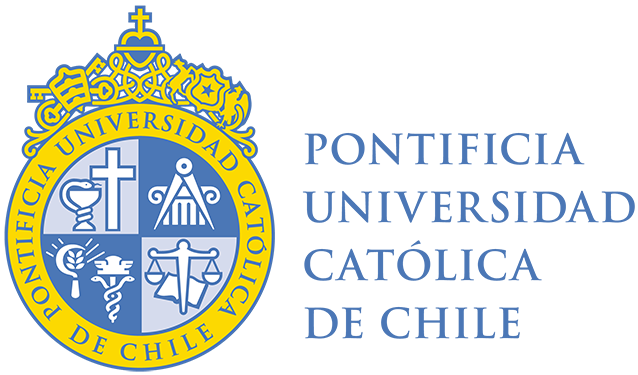
</div>

<table style="margin: auto; border-collapse: collapse; font-size: 14px;">
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Curso:</td>
        <td style="padding: 4px 15px; text-align: left;">IMT3860 — Introducción a Data Science</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Actividad:</td>
        <td style="padding: 4px 15px; text-align: left;">Taller: Exploración adicional de la GSS (EDA)</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Alumno:</td>
        <td style="padding: 4px 15px; text-align: left;">Armando Arredondo Valencia</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Fecha:</td>
        <td style="padding: 4px 15px; text-align: left;">Mayo 2026</td></tr>
    <tr><td style="padding: 4px 15px; text-align: right; font-weight: bold;">Institución:</td>
        <td style="padding: 4px 15px; text-align: left;">Pontificia Universidad Católica de Chile</td></tr>
</table>

## Pregunta 1. Caracterización general de la muestra según variables demográficas

**Objetivo:** Describir la composición de la muestra del GSS a lo largo del tiempo usando las variables `year`, `sex`, `race`, `age` y `educ`. Se busca identificar si la muestra ha cambiado en su composición demográfica.


In [ ]:
# --- Pregunta 1: Caracterización demográfica ---

# Valores faltantes en las variables de interés
vars_demo = ["year", "sex", "race", "age", "educ"]
print("Valores faltantes en variables demográficas:")
display(gss[vars_demo].isna().sum().to_frame(name="NaN"))
print()

# 1. Observaciones por año de encuesta
obs_year = gss["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
obs_year.plot(kind="line", marker="o", ax=ax)
ax.set_title("Número de observaciones por año de encuesta")
ax.set_xlabel("Año")
ax.set_ylabel("Número de encuestados")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 2. Distribución por sexo y raza (conteos y porcentajes)
pv_counts = pd.pivot_table(
    gss, index="sex", columns="race",
    values="year", aggfunc="count", margins=True
)
print("Conteo de encuestados por sexo y raza:")
display(pv_counts)

total = pv_counts.loc["All", "All"]
pv_pct = (pv_counts / total * 100).round(1)
print("\nPorcentaje del total:")
display(pv_pct)


In [ ]:
# 3. Edad y educación promedio (general)
print(f"Edad promedio: {gss['age'].mean():.1f} años")
print(f"Educación promedio: {gss['educ'].mean():.1f} años")
print()

# 4. Evolución temporal de edad y educación promedio
trend = gss.groupby("year").agg(
    edad_promedio=("age", "mean"),
    educ_promedio=("educ", "mean"),
    n=("age", "count")
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(trend.index, trend["edad_promedio"], "o-")
axes[0].set_title("Edad promedio por año de encuesta")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Edad promedio")
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(trend.index, trend["educ_promedio"], "o-", color="tab:orange")
axes[1].set_title("Educación promedio por año de encuesta")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Años de educación promedio")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(trend)


**Análisis de resultados.**

La muestra del GSS presenta variaciones importantes en su tamaño a lo largo de los años, reflejando cambios en el diseño muestral y financiamiento de la encuesta.

En cuanto a la composición demográfica, la muestra tiene una representación mayoritaria de personas blancas y de mujeres, consistente con la demografía de EE.UU. y con las tasas de respuesta típicas de encuestas sociales.

Se observa una tendencia clara al alza en los **años de educación promedio**, que aumenta gradualmente a lo largo de las décadas, esperable dado el acceso creciente a educación superior. La **edad promedio** también muestra una leve tendencia ascendente, coherente con el envejecimiento poblacional.

Estos patrones son relevantes porque cualquier análisis posterior (por ejemplo, educación-ingreso) puede estar influido por cambios en la composición de la muestra a lo largo del tiempo.


---

## Pregunta 2. Educación e ingreso: comparación exploratoria entre grupos

**Objetivo:** Analizar cómo varía el ingreso real según el nivel educacional, agrupando a los encuestados en tres categorías: Media o menos (≤12), Pregrado (13–16) y Postgrado (>16).


In [ ]:
# --- Pregunta 2: Educación e ingreso ---
from pandas.api.types import CategoricalDtype

orden_educ = ["Media o menos", "Pregrado", "Postgrado"]
cat_type = CategoricalDtype(categories=orden_educ, ordered=True)

def clasificar_educ(e):
    if pd.isna(e): return np.nan
    elif e <= 12: return "Media o menos"
    elif e <= 16: return "Pregrado"
    else: return "Postgrado"

gss["nivel_educ"] = gss["educ"].apply(clasificar_educ).astype(cat_type)

print("Observaciones por nivel educacional:")
display(gss["nivel_educ"].value_counts().to_frame(name="n"))
print(f"Valores faltantes en realinc: {gss['realinc'].isna().sum()}")


In [ ]:
# Tabla resumen: media, mediana, std, Q25, Q75 por nivel educacional
resumen_educ = gss.groupby("nivel_educ", observed=False)["realinc"].agg(
    ["count", "mean", "median", "std"]
).round(0)

resumen_educ["Q25"] = gss.groupby("nivel_educ", observed=False)["realinc"].quantile(0.25).values
resumen_educ["Q75"] = gss.groupby("nivel_educ", observed=False)["realinc"].quantile(0.75).values

resumen_educ.columns = ["n", "Media", "Mediana", "Desv. Est.", "Q25", "Q75"]
print("Resumen de ingreso real por nivel educacional:")
display(resumen_educ)

print("\nNota: la diferencia entre media y mediana indica asimetría positiva")
print("(hay valores extremos altos que elevan la media por encima de la mediana).")


In [ ]:
# Boxplot por nivel educacional
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=gss, x="nivel_educ", y="realinc", order=orden_educ, ax=axes[0])
axes[0].set_title("Distribución de ingreso real por nivel educacional")
axes[0].set_xlabel("Nivel educacional")
axes[0].set_ylabel("Ingreso real")

sns.boxplot(data=gss, x="nivel_educ", y="realinc", order=orden_educ,
            showfliers=False, ax=axes[1])
axes[1].set_title("Distribución de ingreso (sin outliers)")
axes[1].set_xlabel("Nivel educacional")
axes[1].set_ylabel("Ingreso real")

plt.tight_layout()
plt.show()


In [ ]:
# CDF empírica de ingresos por nivel educacional
fig, ax = plt.subplots(figsize=(10, 5))

for nivel in orden_educ:
    datos = gss.loc[gss["nivel_educ"] == nivel, "realinc"].dropna()
    cdf = CDF(datos)
    cdf.plot(ax=ax, label=nivel, drawstyle="steps-post")

ax.set_title("CDF empírica de ingreso real por nivel educacional")
ax.set_xlabel("Ingreso real")
ax.set_ylabel("Probabilidad acumulada")
ax.legend()
ax.set_xlim(0, 150000)
plt.tight_layout()
plt.show()


**Análisis de resultados.**

1. **El ingreso promedio aumenta claramente con el nivel educacional.** Los encuestados con postgrado tienen un ingreso promedio sustancialmente mayor que los de pregrado, y estos a su vez mayor que los de media o menos.

2. **La diferencia no se limita al promedio, sino que se observa en toda la distribución.** Las CDF empíricas muestran que la distribución de postgrado está consistentemente desplazada hacia la derecha. La ventaja no es solo en el promedio, sino en toda la distribución de ingresos.

3. **El grupo con mayor dispersión es Postgrado**, con la mayor desviación estándar y rango intercuartílico más amplio: hay variabilidad considerable dentro de este grupo.

4. **Precauciones interpretativas:** la media es mayor que la mediana en todos los grupos (asimetría positiva). Además, esta comparación no controla por edad, sexo, raza ni cohorte generacional, por lo que no puede interpretarse como un efecto causal de la educación sobre el ingreso.


---

## Pregunta 3. Edad, educación e ingreso: análisis por perfiles

**Objetivo:** Estudiar cómo el ingreso real varía con la edad y si ese patrón depende del nivel educacional.


In [ ]:
# --- Pregunta 3: Edad, educación e ingreso ---
orden_edad = ["18-29", "30-44", "45-59", "60+"]
cat_edad = CategoricalDtype(categories=orden_edad, ordered=True)

def clasificar_edad(a):
    if pd.isna(a): return np.nan
    elif a <= 29: return "18-29"
    elif a <= 44: return "30-44"
    elif a <= 59: return "45-59"
    else: return "60+"

gss["grupo_edad"] = gss["age"].apply(clasificar_edad).astype(cat_edad)

# Tabla pivote: ingreso promedio por grupo de edad y nivel educacional
pv_income = pd.pivot_table(
    gss, values="realinc", index="grupo_edad",
    columns="nivel_educ", aggfunc="mean", observed=False
).round(0)

print("Ingreso promedio por grupo de edad y nivel educacional:")
display(pv_income)

# Tabla de conteos (n por celda)
pv_n = pd.pivot_table(
    gss, values="realinc", index="grupo_edad",
    columns="nivel_educ", aggfunc="count", observed=False
).round(0)

print("\nNúmero de observaciones por celda:")
display(pv_n)


In [ ]:
# Mapa de calor del ingreso promedio y conteos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pv_income, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Ingreso promedio por edad y educación")
axes[0].set_ylabel("Grupo de edad")

sns.heatmap(pv_n, annot=True, fmt=".0f", cmap="Blues", ax=axes[1])
axes[1].set_title("Número de observaciones por celda")
axes[1].set_ylabel("Grupo de edad")

plt.tight_layout()
plt.show()


In [ ]:
# Gráfico de barras agrupadas
pv_income.plot(kind="bar", figsize=(10, 5))
plt.title("Ingreso promedio por grupo de edad y nivel educacional")
plt.xlabel("Grupo de edad")
plt.ylabel("Ingreso promedio real")
plt.xticks(rotation=0)
plt.legend(title="Nivel educacional")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Análisis de resultados.**

1. **Los mayores ingresos promedio se observan en el tramo 45–59 años**, esperable por encontrarse en la etapa de mayor experiencia laboral y desarrollo profesional.

2. **El efecto aparente de la edad no es igual para todos los niveles educacionales.** Para personas con postgrado, el ingreso crece de forma más pronunciada con la edad y la brecha se amplía en tramos intermedios. Para media o menos, el crecimiento es más modesto.

3. **Existen combinaciones con pocas observaciones**, especialmente postgrado para edades jóvenes (18–29), lo cual tiene sentido porque a esa edad pocos han completado un postgrado. Esos promedios deben interpretarse con cautela.

4. **El patrón más relevante es la interacción entre educación y edad:** la educación parece amplificar el retorno del ingreso con la experiencia. Sin embargo, esto no implica causalidad; factores como ocupación, sector económico y cohorte generacional también influyen.


---

## Pregunta 4. Análisis avanzado: predicción exploratoria de ingreso y discusión crítica

**Objetivo:** Construir un modelo de regresión exploratoria para estudiar qué variables están más asociadas al ingreso real, generar perfiles de predicción y discutir limitaciones causales.


In [ ]:
# --- Pregunta 4: Regresión exploratoria ---
import statsmodels.formula.api as smf

vars_modelo = ["realinc", "age", "educ", "sex", "race"]
gss_reg = gss[vars_modelo].dropna().copy()
gss_reg = gss_reg[gss_reg["realinc"] > 0]

print(f"Observaciones originales: {len(gss)}")
print(f"Observaciones en regresión: {len(gss_reg)}")
print(f"Observaciones eliminadas: {len(gss) - len(gss_reg)}")
print()

# Modelo OLS con errores robustos (HC3)
formula = "realinc ~ age + I(age**2) + educ + I(educ**2) + C(sex) + C(race)"
modelo = smf.ols(formula, data=gss_reg).fit(cov_type="HC3")

print("Resumen del modelo:")
display(modelo.summary())


In [ ]:
# Perfil 1: misma edad (40 años), variando educación
educ_range = np.arange(8, 21)
pred_educ = pd.DataFrame({
    "age": 40, "educ": educ_range,
    "sex": "male", "race": "white"
})
pred_educ["y_pred"] = modelo.predict(pred_educ)

# Perfil 2: misma educación (16 años), variando edad
age_range = np.arange(20, 76)
pred_age = pd.DataFrame({
    "age": age_range, "educ": 16,
    "sex": "male", "race": "white"
})
pred_age["y_pred"] = modelo.predict(pred_age)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pred_educ["educ"], pred_educ["y_pred"], "o-")
axes[0].set_title("Ingreso predicho variando educación (edad=40, hombre, blanco)")
axes[0].set_xlabel("Años de educación")
axes[0].set_ylabel("Ingreso predicho")
axes[0].grid(alpha=0.3)

axes[1].plot(pred_age["age"], pred_age["y_pred"], "-")
axes[1].set_title("Ingreso predicho variando edad (educ=16, hombre, blanco)")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Ingreso predicho")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Perfil 3: comparación por sexo y nivel educacional, edad fija = 40
perfiles = []
for sexo in ["male", "female"]:
    for ed in [12, 16, 20]:
        row = pd.DataFrame({
            "age": [40], "educ": [ed],
            "sex": [sexo], "race": ["white"]
        })
        row["y_pred"] = modelo.predict(row)
        row["perfil"] = f"{sexo}, educ={ed}"
        perfiles.append(row)

df_perfiles = pd.concat(perfiles, ignore_index=True)

print("Ingreso predicho para distintos perfiles (edad=40, raza=blanco):")
display(df_perfiles[["perfil", "sex", "educ", "y_pred"]].round(0))

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"male": "tab:blue", "female": "tab:orange"}

for sexo in ["male", "female"]:
    sub = df_perfiles[df_perfiles["sex"] == sexo]
    ax.bar(
        [f"{sexo}\neduc={int(e)}" for e in sub["educ"]],
        sub["y_pred"], color=colors[sexo],
        label=sexo, alpha=0.8
    )

ax.set_title("Ingreso predicho por sexo y nivel educacional (edad=40)")
ax.set_ylabel("Ingreso predicho")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**Análisis de resultados.**

1. **Las variables más asociadas al ingreso son educación y edad**, ambas con términos cuadráticos significativos. La educación presenta un efecto acelerado: cada año adicional aporta más que el anterior. La edad muestra una curva en U invertida, con pico alrededor de los 45–55 años.

2. **Cuando se controla por edad, el efecto de la educación se mantiene fuerte.** La asociación educación-ingreso no se debe solamente a que las personas más educadas son mayores.

3. **Los perfiles hipotéticos muestran diferencias claras:**
   - A igual edad, pasar de 12 a 16 años de educación genera un incremento sustancial.
   - A igual educación, el ingreso crece con la edad hasta un máximo y luego desciende.
   - Se observan diferencias por sexo: el modelo predice ingresos menores para mujeres en iguales condiciones, reflejando una brecha salarial presente en los datos.

**¿Por qué este análisis no permite concluir causalidad?**

1. **Datos observacionales:** los encuestados no fueron asignados aleatoriamente a niveles de educación. Quienes estudian más podrían diferir en habilidades, motivación o entorno socioeconómico familiar (sesgo de selección).

2. **Variables omitidas:** el modelo no incluye ocupación, sector económico, región geográfica, experiencia laboral, estado civil ni ingreso familiar de origen, que pueden confundir la relación educación-ingreso.

3. **Efectos de cohorte y temporales:** los datos cubren varias décadas. Una persona con 16 años de educación en 1975 tiene un perfil muy distinto a una en 2018. El modelo no distingue estas diferencias generacionales.

Además, el análisis no incorpora ponderadores muestrales (survey weights), lo que podría afectar la representatividad.


---

## Conclusión final

El hallazgo más interesante de este análisis es la **interacción entre educación y edad**: la ventaja de ingresos asociada a mayor educación se amplifica con la experiencia laboral, y el modelo cuadrático captura bien esta dinámica no lineal. La brecha educacional es moderada en edades jóvenes pero se vuelve sustancial en edades intermedias.

La limitación más importante es que todos los resultados son **asociaciones descriptivas**, no efectos causales. La omisión de variables clave como ocupación, región y entorno socioeconómico de origen impide atribuir las diferencias de ingreso exclusivamente a la educación o la edad. Cualquier conclusión de política pública requeriría un diseño de investigación más robusto.
